<a href="https://colab.research.google.com/github/SangeetBarkataki10/CS105Minproject-SSTMA/blob/main/SSTMA_CS105.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETL Pipeline

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("CS105_data.csv")
# Agreement metric: "Rate your level of agreement:  [Utilizing AI helps me understand material]"
column_mapping = {
    # Demographics
    2: "Class Standing",
    13: "Cumulative GPA",

    # AI Reliance
    42: "LLM Frequency (ChatGPT)",
    43: "LLM Frequency (Claude)",
    44: "LLM Frequency (Gemini)",
    46: "LLM Frequency (Copilot)",
    47: "LLM Frequency (Perplexity)",
    48: "LLM Frequency (Deepseek)",
    86: "Math Usage",
    88: "CS Usage",
    89: "Data Science Usage",
    99: "AI Chatbot Usage",

    # Confidence in Original Work
    53: "Coding Self Confidence",
    54: "Research Self Confidence",
    55: "Data Analysis Self Confidence",
    56: "Writing Self Confidence",
    57: "Topic Summarization Self Confidence",
    107: "Agreement",
    62: "Overreliance Concern",
    59: "Loss of Learning Concern",

    # Trust in AI vs Need for Verification
    92: "Math Trust",
    94: "CS Trust",
    95: "Data Science Trust",
    61: "Hallucinations/Wrong Answers"
}

columns_to_keep = list(column_mapping.keys())
df_clean = df.iloc[:, columns_to_keep].copy()

rename_dict = {df.columns[i]: new_name for i, new_name in column_mapping.items()}
df_clean = df_clean.rename(columns=rename_dict)
df_clean.dropna(inplace=True)

df_clean.to_csv("CS105_data_clean.csv", index=False)

df_clean.head()

,Class Standing,Cumulative GPA,LLM Frequency (ChatGPT),LLM Frequency (Claude),LLM Frequency (Gemini),LLM Frequency (Copilot),LLM Frequency (Perplexity),LLM Frequency (Deepseek),Math Usage,CS Usage,...,Data Analysis Self Confidence,Writing Self Confidence,Topic Summarization Self Confidence,Agreement,Overreliance Concern,Loss of Learning Concern,Math Trust,CS Trust,Data Science Trust,Hallucinations/Wrong Answers
0,Senior,3.33 – 3.67,Use Frequently,Never Used,Used 1-2 times,Never Used,Never Used,Never Used,2.0,1.0,...,Fairly Confident,Very Confident,Very Confident,4.0,4 (Moderately influential),5 (Extremely influential),2.0,2.0,2.0,4 (Moderately influential)
1,Junior,3.67 – 4.0,Use Rarely,Never Used,Use Rarely,Use Rarely,Never Used,Never Used,2.0,3.0,...,Fairly Confident,Very Confident,Very Confident,1.0,5 (Extremely influential),4 (Moderately influential),4.0,4.0,4.0,3 (Partially Influential)
2,Junior,3.33 – 3.67,Use Frequently,Use Frequently,Use Rarely,Never Used,Never Used,Never Used,2.0,2.0,...,Somewhat Confident,Fairly Confident,Fairly Confident,2.0,3 (Partially Influential),2 (Somewhat influential),1.0,2.0,1.0,2 (Somewhat influential)
3,Senior,3.33 – 3.67,Use Frequently,Use Frequently,Used 1-2 times,Use Rarely,Never Used,Never Used,0.0,4.0,...,Somewhat Confident,Very Confident,Very Confident,5.0,5 (Extremely influential),5 (Extremely influential),5.0,5.0,0.0,2 (Somewhat influential)
4,Junior,3.33 – 3.67,Use Frequently,Never Used,Use Frequently,Use Frequently,Never Used,Use Rarely,2.0,2.0,...,Somewhat Confident,Somewhat Confident,Somewhat Confident,2.0,5 (Extremely influential),4 (Moderately influential),5.0,5.0,5.0,4 (Moderately influential)


Group sizes:
GPA Tier
< 2.67         16
2.67 – 3.0     15
3.0 – 3.33     39
3.33 – 3.67    64
3.67 – 4.0     66
Name: count, dtype: int64

Mean scores by GPA tier:
             AI Chatbot Usage  CS Trust  CS Usage  Coding Self Confidence
GPA Tier                                                                 
< 2.67                   2.88      3.50      2.81                    3.31
2.67 – 3.0               2.00      2.20      2.33                    3.07
3.0 – 3.33               3.31      3.38      2.82                    3.03
3.33 – 3.67              2.70      3.59      2.38                    3.30
3.67 – 4.0               2.98      3.67      3.15                    3.05


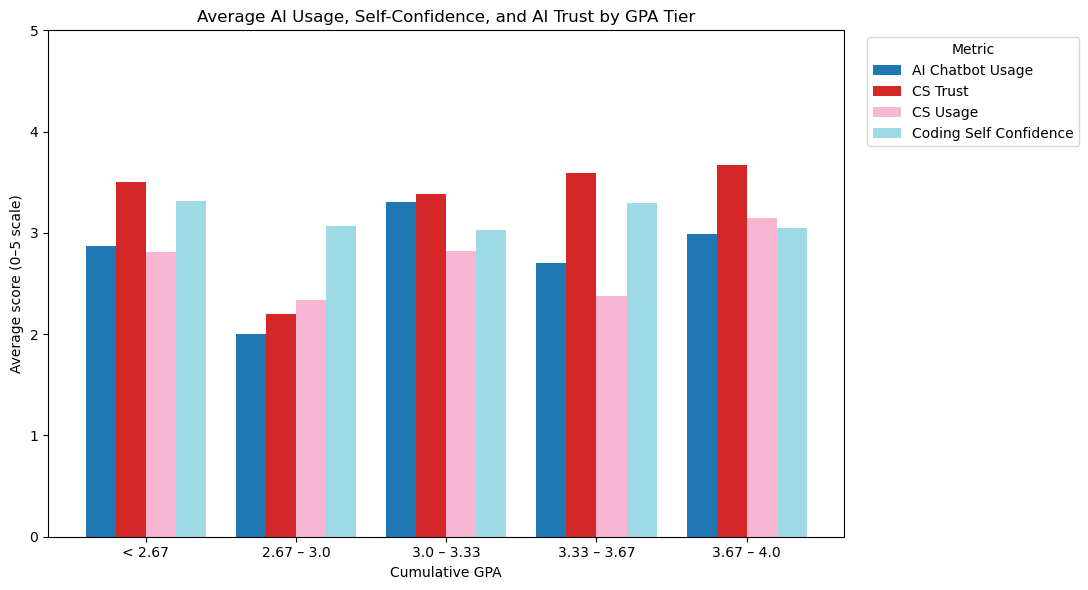

In [5]:
confidence_map = {'Slightly Confident': 1, 'Somewhat Confident': 2, 'Fairly Confident': 3,
                  'Mostly Confident': 4, 'Very Confident': 5}

conf_cols = ['Coding Self Confidence', 'Research Self Confidence',
             'Data Analysis Self Confidence', 'Writing Self Confidence',
             'Topic Summarization Self Confidence']

for c in conf_cols:
    if df_clean[c].dtype == 'object':
        df_clean[c] = df_clean[c].map(confidence_map)

df_gpa = df_clean[df_clean['Cumulative GPA'] != 'Prefer not to say'].copy()
df_gpa['GPA Tier'] = df_gpa['Cumulative GPA'].replace({
    '1.67 – 2.0':  '< 2.67',
    '2.0 – 2.33':  '< 2.67',
    '2.33 – 2.67': '< 2.67',
})

gpa_order = ['< 2.67', '2.67 – 3.0', '3.0 – 3.33', '3.33 – 3.67', '3.67 – 4.0']

metrics = df_gpa.pivot_table(
    values=['CS Usage', 'AI Chatbot Usage', 'Coding Self Confidence', 'CS Trust'],
    index='GPA Tier',
    aggfunc='mean'
).reindex(gpa_order)

print("Group sizes:")
print(df_gpa['GPA Tier'].value_counts().reindex(gpa_order))
print("\nMean scores by GPA tier:")
print(metrics.round(2))

metrics.plot(kind='bar', figsize=(11, 6), colormap='tab20', width=0.8)
plt.title('Average AI Usage, Self-Confidence, and AI Trust by GPA Tier')
plt.xlabel('Cumulative GPA')
plt.ylabel('Average score (0–5 scale)')
plt.xticks(rotation=0)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

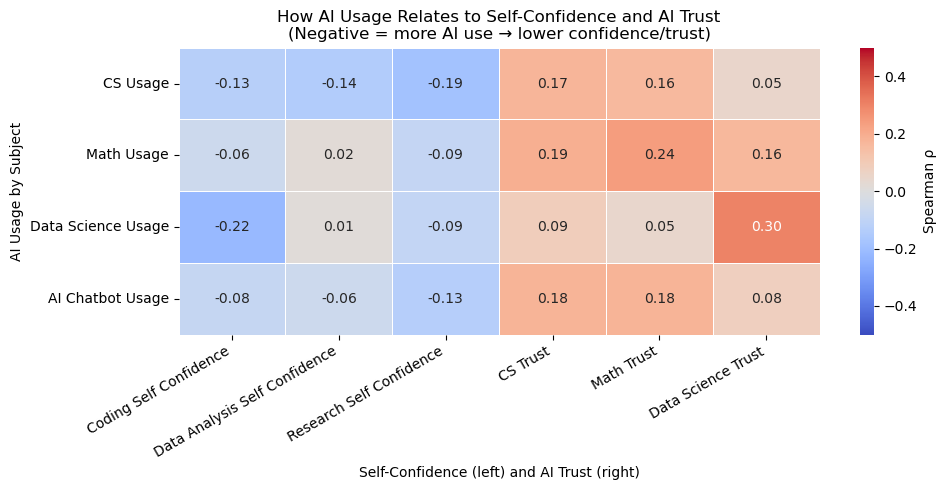

In [6]:
usage_vars = ['CS Usage', 'Math Usage', 'Data Science Usage', 'AI Chatbot Usage']
outcome_vars = ['Coding Self Confidence', 'Data Analysis Self Confidence',
                'Research Self Confidence', 'CS Trust', 'Math Trust', 'Data Science Trust']

corr_matrix = df_clean[usage_vars + outcome_vars].corr(method='spearman')
focused = corr_matrix.loc[usage_vars, outcome_vars]

plt.figure(figsize=(10, 5))
sns.heatmap(focused, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, linewidths=0.5,
            cbar_kws={'label': 'Spearman ρ'})
plt.title('How AI Usage Relates to Self-Confidence and AI Trust\n'
          '(Negative = more AI use → lower confidence/trust)')
plt.xlabel('Self-Confidence (left) and AI Trust (right)')
plt.ylabel('AI Usage by Subject')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import chi2_contingency

# Ho: GPA tier and overreliance concern are independent
# Ha: GPA tier and overreliance concern are NOT independent

df_test = df_clean.copy()

influence_map = {'1 (Not at all/haven’t thought about it)': 1, '2 (Somewhat influential)': 2,
                 '3 (Partially Influential)': 3, '4 (Moderately influential)': 4,
                 '5 (Extremely influential)': 5}
df_test['Overreliance Concern'] = df_test['Overreliance Concern'].map(influence_map)

df_test = df_test[df_test['Cumulative GPA'] != 'Prefer not to say']
df_test['GPA Tier'] = df_test['Cumulative GPA'].replace({
    '1.67 – 2.0':  '< 2.67',
    '2.0 – 2.33':  '< 2.67',
    '2.33 – 2.67': '< 2.67',
})

df_test['Overreliance (binned)'] = df_test['Overreliance Concern'].replace(
    {1: '1-2 (Low)', 2: '1-2 (Low)', 3: '3 (Mid)', 4: '4 (High)', 5: '5 (Very High)'})

ct = pd.crosstab(df_test['GPA Tier'], df_test['Overreliance (binned)'])

# Chi-squared test
chi2, p, dof, expected = chi2_contingency(ct)

print(f"chi-square = {chi2:.2f}")
print(f"p  = {p:.4f}")
print(f"dof = {dof}")
print(f"\n{'Reject H0' if p < 0.05 else 'Fail to reject H0'} at alpha = 0.05")

chi-square = 23.13
p  = 0.0266
dof = 12

Reject H0 at alpha = 0.05


In [12]:
# Exploring the Relationship GPA and Overreliance Concern

**Ho:** GPA tier and overreliance concern are independent.
**Ha:** GPA tier and overreliance concern are ~NOT~ independent.

We would like to explore the relationship (or lack thereof) between GPA and Overreliance Concern of AI usage. In order to
examine the relationship, we apply a chi-square test of indpendence to determine independence.

This test uses the crosstab of GPA tiers and Overreliance (which we bin the lower two states) and examine the surveyed values compared to the
expected values of two independent variables.


The chi-square test of independence returns a value of 23.13 and with p < 0.05, we reject the Ho. Thus, GPA tier and overreliance concern are NOT independent.

This suggests that overreliance concern d

SyntaxError: invalid character '²' (U+00B2) (1691542094.py, line 25)